# Exercise 3 - Odometry Motion Model [10.0]

**_DISCLAIMER:_** The notation used in this exercise follows the one of the Probabilistic Robotics book (refer to Chapter 5.4).

---

In [9]:
from ex3 import *

#Autoloads evertyhing flaged with %aimport
%load_ext autoreload    
%autoreload 1               
%aimport ex3  

#Matplotlib output to cell
%matplotlib inline   


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## 3.1 Inverse motion model [1.0]

The inverse odometry model computes the _relative motion information_ between two poses.
The function `inverse_motion_model` takes as input an:

- the previous pose of the robot ${x}_{t-1} = [x_{t-1},y_{t-1},\theta_{t-1}]$
- the current pose of the robot ${x}_t = [{x}_{t},y_{t},\theta_{t}]$

The output is the relative motion between the poses: 

- $\delta_{rot1}, \delta_{trans}, \delta_{rot2}$.

Implement the function `inverse_motion_model`. 

**Hint:** For the input $x_{t-1} = [0.0, 0.0, 0.0]$ and $x_{t} = [4, 3, 0]$, the result should be $\delta_{trans} = 5$ and $\delta_{rot1} = -\delta_{rot2}$. 

In [3]:
x_t_1 = [0, 0, 0] 
x_t = [4, 3, 0]

rot1, trans, rot2 = inverse_motion_model(x_t_1,x_t)
print("deltas = ", [rot1, trans, rot2])

deltas =  [np.float64(0.6435011087932844), np.float64(5.0), np.float64(-0.6435011087932844)]


---
## 3.2 Odometry-based motion model [1.0]

The function `motion_model` computes the posterior $p(x_t | u_t, x_{t-1})$ from odometry readings.

This function takes as input:

- the initial pose of the robot $x_{t-1} = [x,y,\theta]$ _(**map** coordinate frame)_
- the hypothesized (or query) final pose $x_{t} = [x', y', \theta']$ _(**map** coordinate frame)_
- the odometry readings $u_t = [\overline{x}_{t-1} \overline{x}_t]$ _(**odometry** coordinate frame)_
- the noise parameters $\mathbf{\alpha} = [\alpha_1, \alpha_2, \alpha_3, \alpha_4]$

The output is the conditional probability density $p(x_t | u_t, x_{t-1})$

Implement the `motion_model` function with the help of the `probability_density` function assuming a noraml distribution. 

**Hint:** The computed probabilty density is not bound bewteen 0 and 1, but always positve !

In [5]:
u_t = [[0.0, 0.0, 0.0], [-4, -3, 0]]
alpha = [1.0, 1.0, 0.01, 0.01]

motion_model(x_t, x_t_1,u_t,alpha)

np.float64(0.003333877532192335)

---
## 3.3 Odometry-based motion model: Part A [2.0]

Consider the 150x150 grid map (the world) with a reex3 of 0.01. The map is centered in the original position of the robot.
This is already in the `plot_posterior_belief` function, where the gridmap, reex3, and origin are initialized.

Assume that a robot starts at pose $x_0 = [2.0, 3.0, 0.0]$ in the map frame and moves according to a motion model with $\mathbf{\alpha} = [0.5, 0.5, 0.01, 0.01]$.

Complete the `plot_posterior_belief` function to plot $p(x_t | u_t, x_{t-1})$ for all possible $[x, y]$ values from the grid. **[2.0]**

**Hint:** Only quering over the grid cells is not enough - integrate over all possible orientations ! 

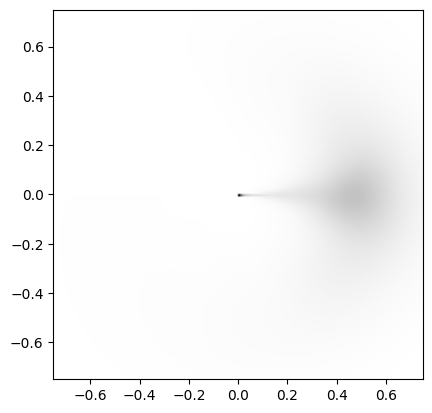

In [7]:
ut = [[0.0, 0.0, 0.0], [0.5, 0.0, np.pi/2]]
x_t_1 = [0, 0, 0.0]
alpha = [0.5, 0.5, 0.01, 0.01]

plot_posterior_belief(x_t_1, ut, alpha)

---
## 3.3 Odometry-based motion model: Part B[1.0]
In scenarios where the final orientaion $\theta$ is not represented (e.g final orientation is irrelevant), the likelihood term coresponding to the second rotation, p3, can be marginalised out.  
This removes the dependecy of the final oritentaion $\theta$ and reduced computation time. However, this marginalization is only an approximation of the true posterior over the full pose space $[x,y,\theta]$, since it does not account for the uncertainty assosicated with the final rotation.

Add the functionality to include marginalisation to the function `plot_posterior_belief` by passing marginalise_p3=True to both `plot_posterior_belief` and `motion_model`.


**Hint:** This simplification changes the visual appearance of the posterior belief!

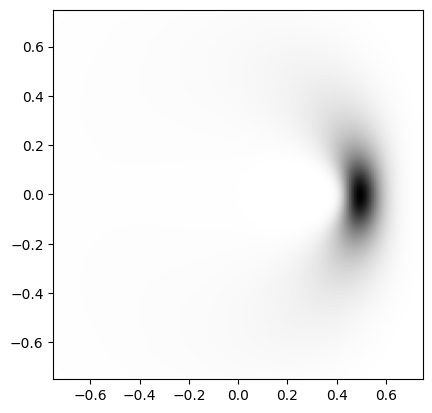

In [8]:
plot_posterior_belief(x_t_1, ut, alpha,marginalise_p3=True)

---
## 3.4 Sample odometry motion model [2.0]

The `motion_model` requires high computation complexity and does not scale well to large real-world environments - even when marginalising. 

One effective approach to approximate $p(x_t | u_t, x_{t-1})$ is to use **sampling**.

The `sample_motion_model` function defines the sampling-based odometry motion model. 

This function takes as input:

- the initial pose of the robot $x_{t-1} = [x,y,\theta]$ _(**map** coordinate frame)_
- the odometry readings $u_t = [\overline{x}_{t-1} \overline{x}_t]$ _(**odometry** coordinate frame)_
- the noise parameters $\mathbf{\alpha} = [\alpha_1, \alpha_2, \alpha_3, \alpha_4]$

The output is a new (sampled) pose predicted by the motion model.

Implement the `sample_motion_model` function and verify that it is correct plotting the results with `plot_sample_motion_model`.

**Hint:** Generate samples with `get_sample` - see lecture to understand why this works !

In [ ]:
ut = [[0.0, 0.0, 0.0], [0.5, 0.0, np.pi/2]]
pose_t_1 = [2.0, 3.0, 0.0]
alpha = [1.0, 1.0, 0.01, 0.01]

plot_sample_motion_model(pose_t_1, ut, alpha)


---
## 3.5 Evaluate sample odometry motion model [3.0]

Assume that a robot starts at pose $x_0 = [2.0, 3.0, 0.0]$ in the map frame and moves according to a motion model with $\mathbf{\alpha} = [0.1, 0.1, 0.01, 0.01]$.

The robot obtains the following odometry readings:

1. $\overline{x}_0 = [0.0 , 0.0 , 0.0   ]$
2. $\overline{x}_1 = [0.5 , 0.0 , \pi/2 ]$
3. $\overline{x}_2 = [0.5 , 0.5 , 0.0   ]$
4. $\overline{x}_3 = [1.0 , 0.5 , 0.0   ]$
5. $\overline{x}_4 = [1.0 , 1.5 , \pi/2 ]$
6. $\overline{x}_5 = [1.0 , 2.5 , \pi/2 ]$

Evaluate the `sample_motion_model` by completing the `evaluate_sample_odometry` function. In particular you need to implement two for-loops: (1) to compute the ground truth poses using the odometry readings; (2) to compute the new samples and current estimated pose.

**Hint:** The estimated pose can be computed as the mean of all samples, but it will not be identical to the ground truth pose.
**Additonal Info:** Even a 2-sigma confidence ellipse can fail to fully capture the real distribution of samples, especially if it is skewed or multi-modal. Therefore, it is common practice to propagate all samples rather than reducing the representation to just the mean or variance.

estimated_poses:  [[2.         3.         0.        ]
 [2.49596388 3.00213717 1.57820835]
 [2.49203064 3.43229065 0.03150023]
 [2.86775459 3.43966133 0.02794915]
 [2.86284551 4.06578988 1.57231187]
 [2.86233421 4.63301021 1.58290236]]


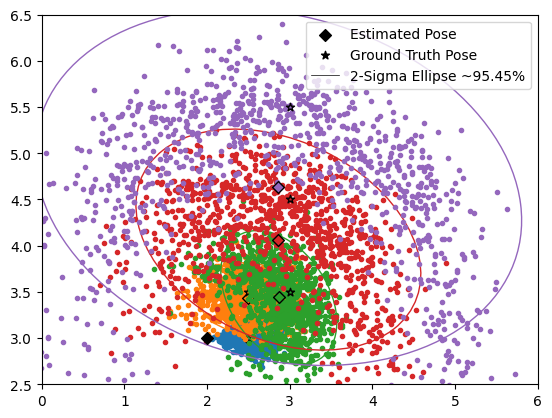

In [10]:
alpha = [0.1, 0.1, 0.01, 0.01]
pose0 = [2.0, 3.0, 0.0]
odom = [[0.0, 0.0, 0.0],
      [0.5, 0.0, np.pi / 2],
      [0.5, 0.5, 0.0],
      [1.0, 0.5, 0.0],
      [1.0, 1.5, np.pi / 2],
      [1.0, 2.5, np.pi / 2]]
odom = np.array(odom)

evaluate_sample_odometry(alpha, pose0, odom)